# Transformée de Fourier

In [13]:
# import
import matplotlib.pyplot as plt; from scipy.io import wavfile
%run ./init.py

## Aliasing / repliement spectral

En présentant le spectre, la FFT permet de directement voir le repliement spectral / aliasing résultant de l'échantillonnage d'un signal à une fréquence trop basse.
Si $f = fs/2 + 4000$, son pic d'énergie sera **replié** à $fs/2 - 4000$.

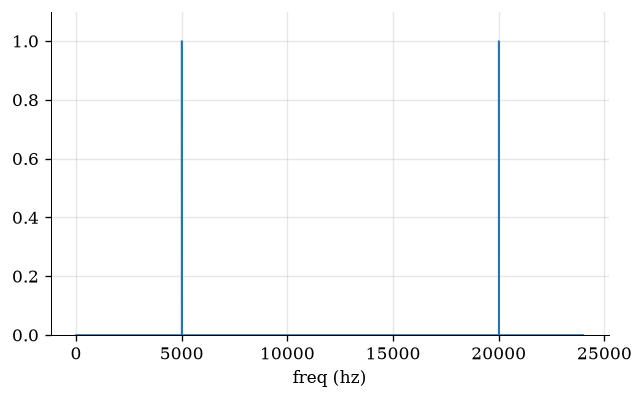

In [14]:
# init locals
f1 = 5000
f2 = fs/2 + 4000

# create signal
x1, t = get_sine(f1, sampling_rate = fs, duration_in_sec = 1)
x2, t = get_sine(f2, sampling_rate = fs, duration_in_sec = 1)
x = x1 + x2 

# fft
n = len(x)
X = np.fft.rfft(x, n)
freqs = np.fft.rfftfreq(n, 1/fs)

# plot fft
plt.plot(freqs, np.abs(X) / len(X), '-');
plt.ylim([0, 1.1]); plt.xlabel('freq (hz)'); plt.show();

## Résolution fréquentielle

Augmenter le nombre de fréquences utilisées permet d'obtenir une courbe fréquentielle plus lissée. (peut être réalisé en augmentant `num_freqs` ou en utilisant du zero padding)

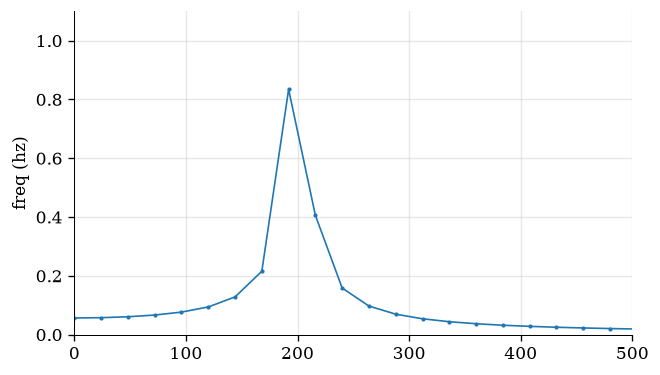

In [15]:
# init locals
num_freqs = 2000

# create signal
x, t = get_sine(200, sampling_rate = fs, duration_in_sec = 1)

# fft
X = np.fft.rfft(x, num_freqs)
freqs = np.fft.rfftfreq(num_freqs, 1/fs)

# plot fft
plt.plot(freqs, np.abs(X) / len(X), '.-');
plt.ylim([0, 1.1]); plt.xlim([0, 500]); plt.ylabel('freq (hz)'); plt.show();

## Pouvoir de séparation fréquentiel

Mais c'est la durée de l'enregistrement original $x(t)$ qui détermine le pouvoir de séparation entre deux fréquences.

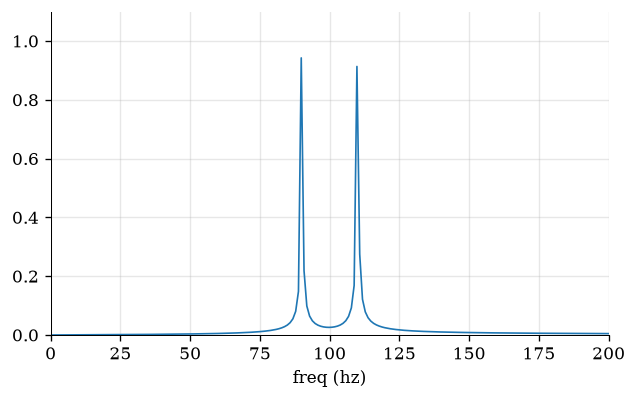

In [16]:
# init locals
duration_in_sec = 1
n_padding = 100

# create signal
x1, t = get_sine(90, sampling_rate = fs, duration_in_sec=duration_in_sec)
x2, t = get_sine(110, sampling_rate = fs, duration_in_sec=duration_in_sec, phase = math.pi/2)
x = x1 + x2

# zero pad end
x = np.pad(x, (0, n_padding))

# fft
n = len(x)
X = np.fft.rfft(x, n)
freqs = np.fft.rfftfreq(n, 1/fs)

# plot fft
plt.plot(freqs, np.abs(X) / len(X));
plt.xlim([0, 200]); plt.ylim([0, 1.1]); plt.xlabel('freq (hz)'); plt.show()

Plus les fréquences sont proches, plus on a besoin de temps (de signal) pour que le battement entre les deux réalise une période entière et fasse s'annuler l'air sous la courbe du produit avec le cos / sin (c.f. notebook fft_deconstruct). 

Comme en musique, plus deux notes sont proches, plus le battement fréquentiel qu'elles produisent est lent : ici il faut donner à la fft au moins une période de battement pour qu'elle soit capable de dissocier deux fréquences. 

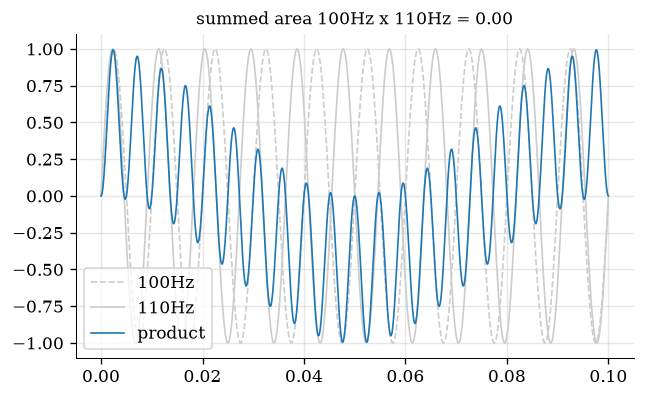

In [17]:
# define signals
f1 = 100; f2 = 110
duration_in_sec = 0.1

# create signals
x1, t = get_sine(f1, sampling_rate = fs, duration_in_sec = duration_in_sec)
x2, t = get_sine(f2, sampling_rate = fs, duration_in_sec = duration_in_sec)

# area under multiplied curves
y = np.multiply(x1, x2)

# plot
plt.plot(t, x1, '--', color = [0.8, 0.8, 0.8], label = f'{f1}Hz')
plt.plot(t, x2, color = [0.8, 0.8, 0.8], label = f'{f2}Hz')
plt.plot(t, y, '-', label = f'product')
plt.title(f'summed area {f1}Hz x {f2}Hz = {(np.sum(y) / len(y)):0.2f}')
plt.legend();

## Convolution temporelle, multiplication fréquentielle

$FFT(h(t) \circledast x(t)) = H(f) . X(f)$, et ça, ça change tout. 

On peut retrouver cette propriété via la formule analytique de la FFT. Intuitivement :
- (tout signal est décomposable en une somme de sinus)
- (la convolution d'une somme est la somme des convolutions)
- si on convolue un sinus pur avec un filtre, le signal de sortie garde la même fréquence, seule son amplitude et sa phase peuvent être modifiées

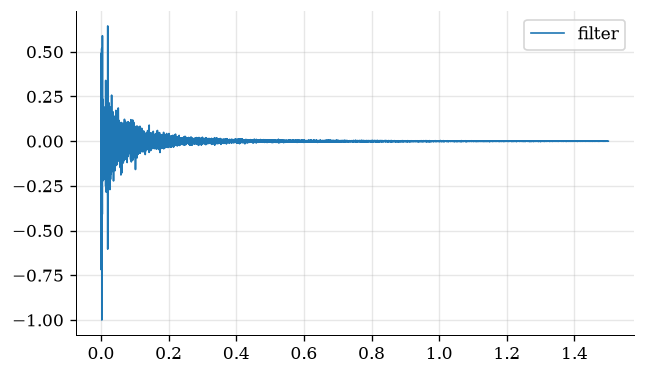

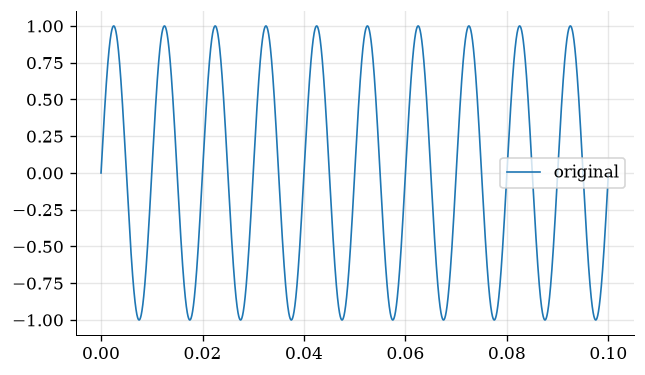

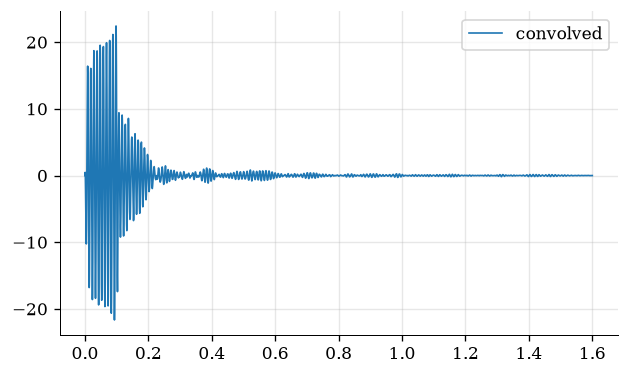

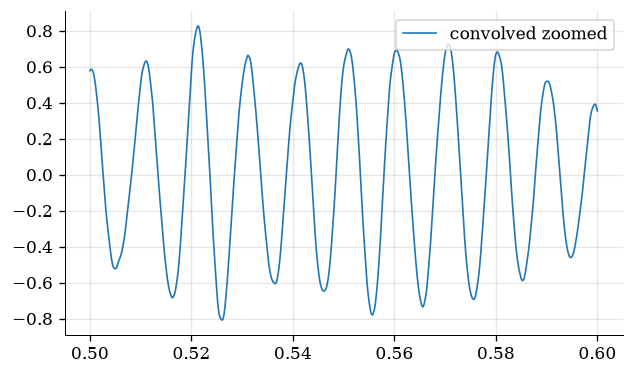

In [18]:
# define signals
f1 = 100
duration_in_sec = 0.1

# create signals
x, t = get_sine(f1, sampling_rate = fs, duration_in_sec = duration_in_sec)

# create filter
h, fs = wavread('assets/ir_mono.wav')
h = h / np.max(np.abs(h))

# convolve
y = np.convolve(x, h)
ty = np.arange(0, len(y))/fs

# plot
t = np.arange(0, len(h)) / fs
plt.plot(t, h, label = 'filter'); plt.legend(); plt.show()
t = np.arange(0, len(x)) / fs
plt.plot(t, x, label = 'original'); plt.legend(); plt.show()
t = np.arange(0, len(y)) / fs
plt.plot(t, y, label = 'convolved'); plt.legend(); plt.show()
selvect = np.multiply(t > 0.5, t < 0.6)
plt.plot(t[selvect], y[selvect], label = 'convolved zoomed'); plt.legend(); plt.show()

l'égalisation réalisée (multiplication fréquentielle) dans `fft_introduction` et la reverb à convolution (convolution temporelle) réalisée dans `convolution_introduction` sont une seule et même opération : **un filtrage avec une FIR**.

L'inverse est vrai: la convolution dans le domaine fréquentiel se transforme en multiplication dans le domaine tempore. $FFT^{-1}(H(f) \circledast X(f)) = h(t).x(t)$

Pouvoir réaliser la même opération dans un domaine ou l'autre (en fonction de ce qui est plus simple, efficace, didactique, etc.) est **une révolution pour le traitement du signal** (audio, image, etc.).


## La vraie transformée de Fourier (et pas la rfft ou fft "réelle")

Le résultat d'une transformée de Fourier classique (np.fft.fft) donne un spectre de fréquences négatives et positives.

Dans le cas d'un signal réel (e.g. signal audio) $x(t)$, on aura toujours $X(-f) = X^{*}(f)$.
Les fréquences négatives ne **contiennent pas d'information supplémentaires**.
On les passera donc sous silence dans la suite.

(elles restent nécessaires pour que la $TF$ et $TF^{-1} fonctionnent mais np.fft.rfft recrée la partie complexe avant projection / reconstruction pour nous).

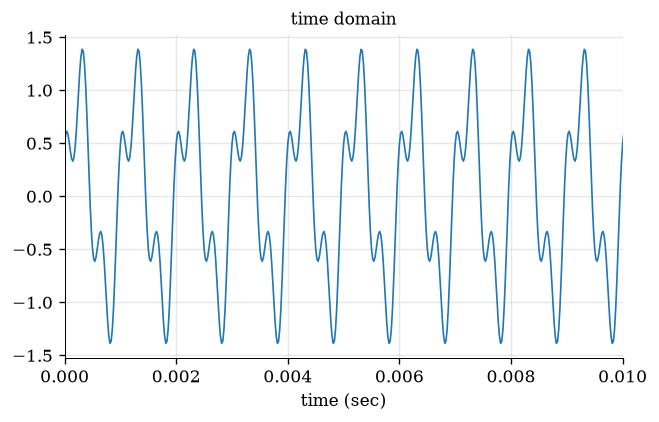

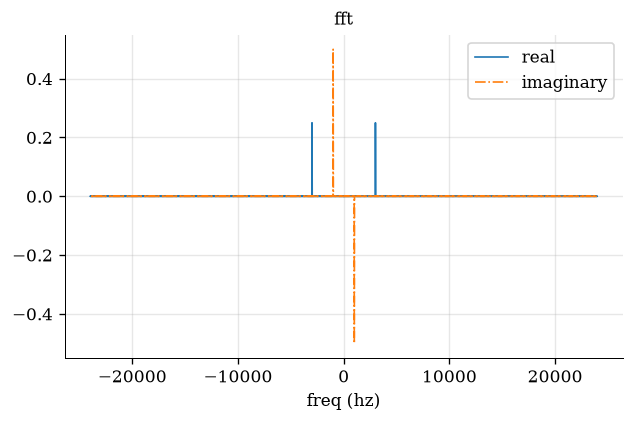

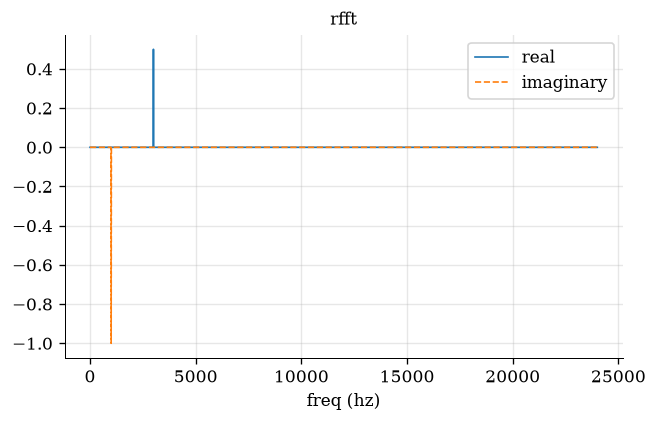

In [19]:
# define signals
f1 = 1000; f2 = 3000
duration_in_sec = 0.1

# create signals
x1, t = get_sine(f1, sampling_rate = fs, duration_in_sec = duration_in_sec, phase = 0)
x2, t = get_sine(f2, sampling_rate = fs, duration_in_sec = duration_in_sec, phase = math.pi/2)
x = x1 + 0.5*x2

# plot fft
plt.plot(t, x);
plt.title('time domain'); plt.xlim([0, 0.01]); plt.xlabel('time (sec)'); plt.show()

# fft
n = len(x)
X = np.fft.fft(x, n) / n
freqs = np.fft.fftfreq(n, 1/fs)

# plot fft
plt.plot(freqs, np.real(X), label = 'real');
plt.plot(freqs, np.imag(X), '-.', label = 'imaginary');
plt.title('fft'); plt.legend(); plt.xlabel('freq (hz)'); plt.show()

# rfft
n = len(x)
X = np.fft.rfft(x, n) / (n/2)
freqs = np.fft.rfftfreq(n, 1/fs)

# plot fft
plt.plot(freqs, np.real(X), label = 'real');
plt.plot(freqs, np.imag(X), '--', label = 'imaginary');
plt.title('rfft'); plt.legend(); plt.xlabel('freq (hz)'); plt.show()
